In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("C:\\Users\\cl103_07\\Downloads\\kyphosis (1).csv")

In [5]:
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


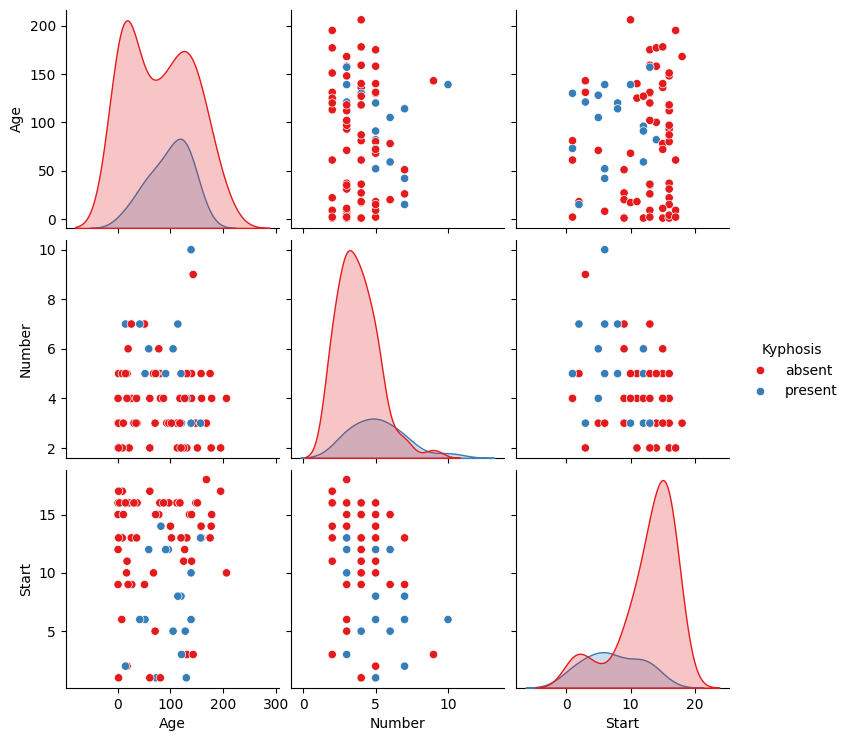

In [6]:
sns.pairplot(df,hue='Kyphosis',palette='Set1')

In [7]:
from sklearn.model_selection import train_test_split

In [9]:
X=df.drop('Kyphosis',axis=1)
y=df['Kyphosis']

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=101)

In [19]:
from sklearn.tree import DecisionTreeClassifier

In [20]:
dtree=DecisionTreeClassifier()

In [21]:
dtree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
from sklearn.metrics import classification_report,confusion_matrix

In [23]:
predict=dtree.predict(X_test)

In [24]:
print(confusion_matrix(y_test,predict))

[[13  4]
 [ 6  2]]


In [25]:
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

      absent       0.68      0.76      0.72        17
     present       0.33      0.25      0.29         8

    accuracy                           0.60        25
   macro avg       0.51      0.51      0.50        25
weighted avg       0.57      0.60      0.58        25



In [26]:
features=list(df.columns[1:])
features

['Age', 'Number', 'Start']

In [27]:
from sklearn import tree

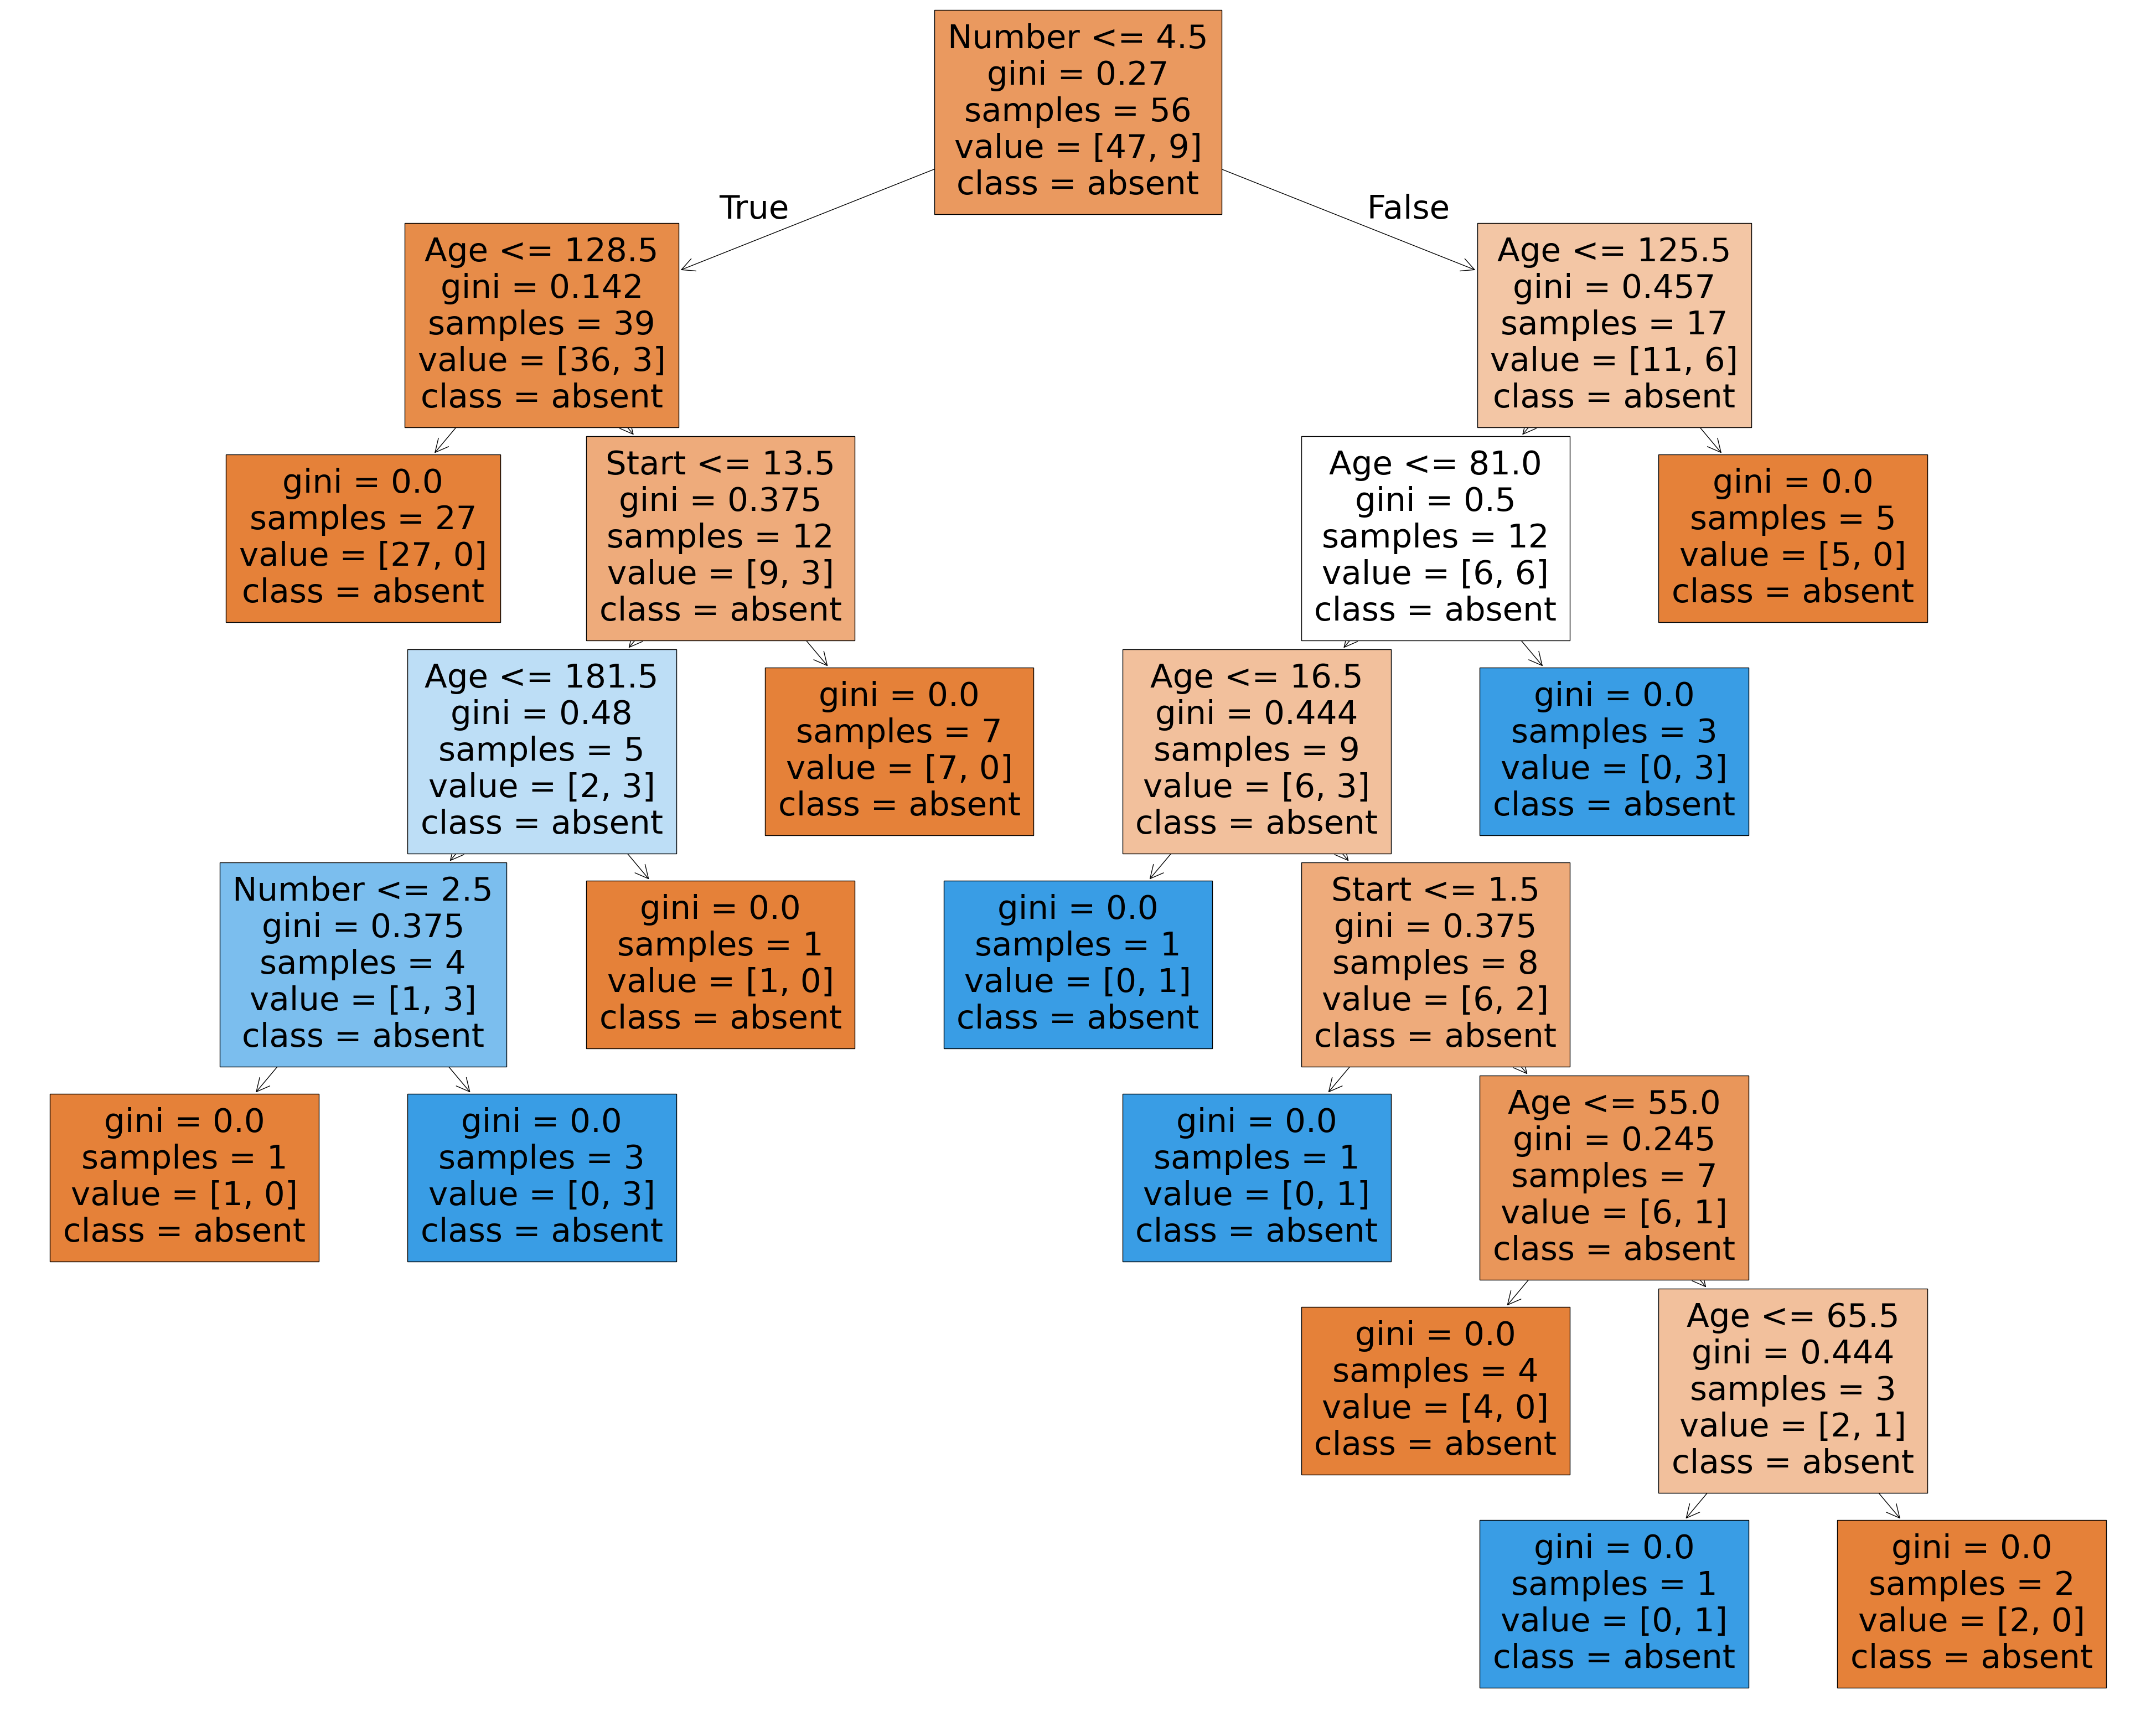

In [35]:
fig=plt.figure(figsize=(50,40))
_=tree.plot_tree(dtree,
                 feature_names=features,
                 class_names=df.Kyphosis,
                 filled=True)

In [40]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(n_estimators=100)
rfc.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
rfc_pred=rfc.predict(X_test)

In [42]:
print(confusion_matrix(y_test,rfc_pred))

[[17  0]
 [ 6  2]]


In [43]:
print(classification_report(y_test,rfc_pred))

              precision    recall  f1-score   support

      absent       0.74      1.00      0.85        17
     present       1.00      0.25      0.40         8

    accuracy                           0.76        25
   macro avg       0.87      0.62      0.62        25
weighted avg       0.82      0.76      0.71        25

